# Tiempo-Frecuencia

Con el análisis de Fourier podemos analizar señales estacionarias de forma inmediata, pero para el caso de señales no estacionarias es dificil extraer información de la transformada que nos hable del orden temporal en el cual se produjeron los eventos no estacionarios. Esta información se encuentra en la fase, y no es evidente como interpretarla. Por ejemplo, tomemos una señal que contienen en diferentes momentos un tono puro y un ruido blanco. La transformada de Fourier nos dirá que la señal tiene componentes en todas las frecuencias, pero no nos dirá cuándo se produjeron esos componentes. Otro ejemplo, una señal oscilatoria cuya frecuencia y amplitud varía en el tiempo, la magnitud de la transformada no puede distinguir la trayectoria en el espacio tiempo-frecuencia. Para resolver este problema, se han desarrollado varias técnicas de análisis de tiempo-frecuencia, que combinan el análisis en el dominio del tiempo y el dominio de la frecuencia.

## Síntesis Tiempo-Frecuencia

Expresemos una señal cuya amplitud y fase varían en el tiempo:

$$
x(t) = A(t) \cdot \cos(\phi(t)) 
$$

La fase $\phi(t)$ es un señal en si misma, y la podemos asociar a un movimiento oscilatorio o un movimiento circular. Podemos pensar en la velocidad a la cual se mueve la fase como una frecuencia instantánea, que se define como la derivada de la fase respecto al tiempo:

$$
\frac{d\phi(t)}{dt} = \omega(t) = 2\pi f(t)
$$

En el caso de un oscilador armónico o un movimiento circular uniforme, la velocidad de la oscilación es constante, por lo que la frecuencia instantánea es constante y coincide con la frecuencia de la señal.

Podemos obtener la fase de una señal a partir de su frecuencia instantánea, integrando la frecuencia respecto al tiempo:

$$
\phi(t) = \int_0^t \omega(t') dt' = 2\pi \int_0^t f(t') dt'
$$

Con este procedimiento podemos sintetizar señales con modulaciones en la frecuencia. A continuación una señal que va de $100Hz$ a $1000Hz$ en un segundo de forma lineal.

$$
x(t) = \cos(2\pi \int_0^t 100 + 900 \cdot \tau d\tau) = \cos(2\pi (100t + 450t^2))
$$

En la figura mostramos la señal, y su trayectoria en un diagrama de tiempo-frecuencia. Finalmente mostramos el error de predición del período instantaneo de la señal en base a medirlo como el tiempo entre picos consecutivos de la onda.

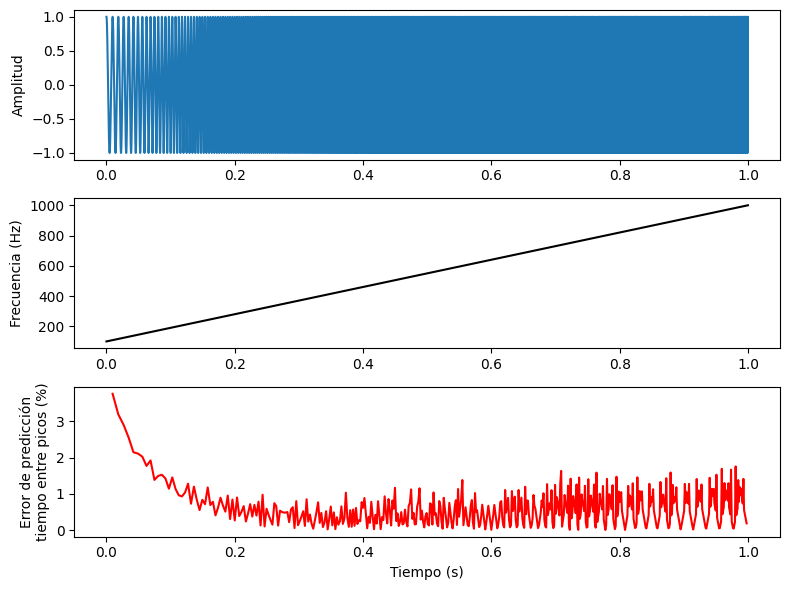

In [1]:
import numpy as np
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy.signal import chirp

# Chirp signl syntehtis numpy
def chirp_signal(t, f0, f1, t1, method='linear'):
    """
    Generate a chirp signal.
    
    Parameters:
    t : array_like
        Time vector.
    f0 : float
        Starting frequency of the chirp.
    f1 : float
        Ending frequency of the chirp.
    t1 : float
        Time at which the frequency is f1.
    method : str
        Method for frequency sweep ('linear', 'quadratic', 'logarithmic').
        
    Returns:
    y : array_like
        Chirp signal.
    """
    if method == 'linear':
        freq = f0 + (f1 - f0) * t / t1
    elif method == 'quadratic':
        freq = f0 + (f1 - f0) * t**2 / t1**2
    elif method == 'logarithmic':
        freq = f0 * (f1 / f0)**(t / t1)
    else:
        raise ValueError(f"Method {method} not implemented")

    dt = t[1] - t[0]
    phi = np.cumsum(freq)*2*np.pi*dt

    return np.cos(phi), freq

sr = 48000
dur = 1
t = np.arange(0, dur, 1/sr)

f0 = 100
f1 = 1000
t1 = 1

x, freq = chirp_signal(t, f0, f1, t1, method='linear')

# find peaks in x
peaks = np.where(np.diff(np.sign(np.diff(x))) < 0)[0]
period = np.diff(peaks)/sr

# Sharex 2,1 subplot
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
axs[0].plot(t, x)
axs[1].plot(t, freq, 'k-')
axs[2].plot(peaks[:-1]/sr, np.abs(period-1/freq[peaks[:-1]])/period*100, 'r')

axs[0].tick_params(axis='x', which='major', labelbottom=True)
axs[1].tick_params(axis='x', which='major', labelbottom=True)
axs[2].tick_params(axis='x', which='major', labelbottom=True)

axs[0].set_ylabel('Amplitud')
axs[1].set_ylabel('Frecuencia (Hz)')
axs[2].set_ylabel('Error de predicción\ntiempo entre picos (%)')
axs[2].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

Audio(x, rate=sr)

## Análisis tiempo-frecuencia

Ahora nos preguntamos como podemos analizar señales en el dominio tiempo-frecuencia. El procedimiento general se basa en tratar de estimar cuanto de la energía de la señal se encuentra en cada frecuencia, y en cada instante de tiempo. Dado que mientras más ciclos tenga una señal mayor más localizada estará su frecuencia, y de forma complementaria, mientras más corta la señal, el contenido en frecuencia se extiende. Este comportamiento implica una limitación en la resolución en el tiempo y la frecuencia. Si queremos medir bien la frecuencia, debemos analizar las señales durante más tiempo, pero esto pierde capacidad de medir con presición el comportamiento en el tiempo. Este es el principio de incertidumbre aplicado al análisis de señales [1]. Si calculamos la varianza de la señal en el tiempo y la frecuencia, podemos ver que existe una relación entre ambas:

$$
\int_{-\infty}^{\infty} t^2 |x(t)|^2 dt \cdot \int_{-\infty}^{\infty}  \omega^2 |X(\omega)|^2 d\omega \geq \frac{1}{4}
$$

O para el desviación estándar de la señal en el tiempo y la frecuencia:

$$
\sigma_t \cdot \sigma_\omega \geq \frac{1}{2}
$$


[1] Cohen, Leon. (1994). Time Frequency Analysis: Theory and Applications. Prentice-Hall Signal Processing

Analicemos el comportamiento de la DFT para estimar la frecuencia de una señal sinusoidal a medida que incluimos más ciclos. En la figura podemos ver que como la resolución en frecuencia $\Delta f = \frac{SR}{N}$ mejora a medida que el largo $N$ crece. 

19951
[12288  6144  3072  1536   768   384   192    96    48    24]



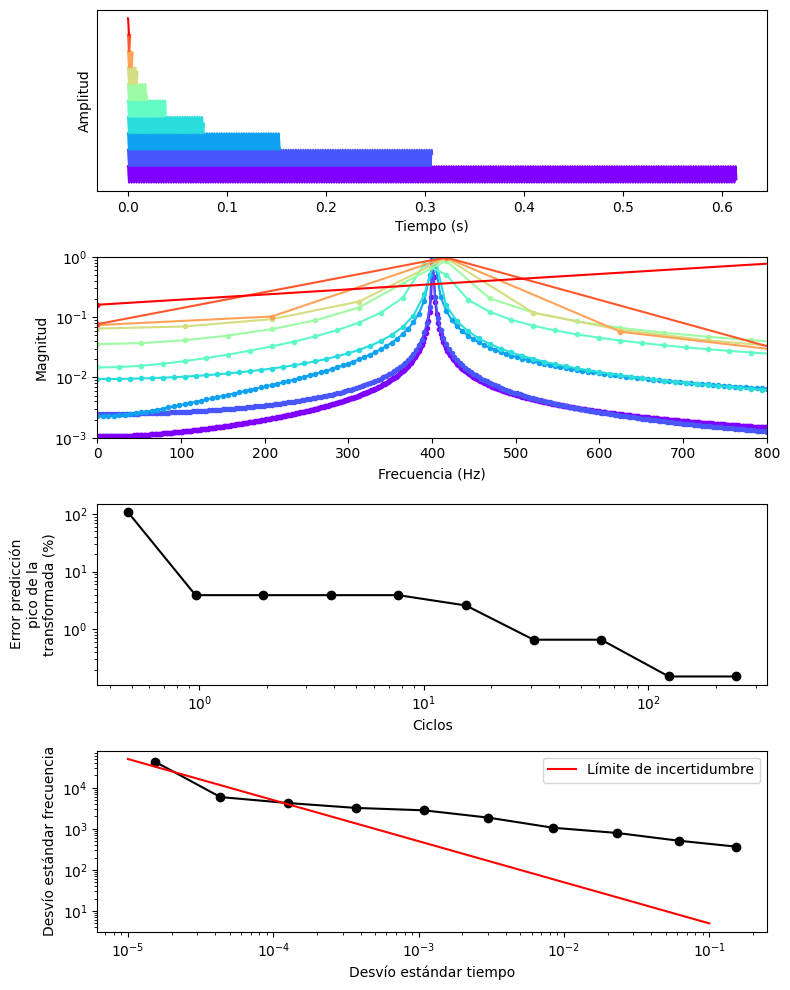

In [ ]:
# cosine wave
sr = 20000  
f0 = 401
dur = 400/f0
t = np.arange(0, dur, 1/sr)
x = np.cos(2*np.pi*f0*t)

fmax = []
sigmas = []

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.rainbow(np.linspace(0, 1, 10)))
fig, axs = plt.subplots(4, 1, figsize=(8, 10))

ks =int(sr/f0/2)*2**np.arange(9, -1,-1)
for i,k in enumerate(ks):
    axs[0].plot(t[:k], x[:k]+i*2)
    
    freqs = np.arange(k//2+1)/k*sr
    X = np.abs(np.fft.rfft(x[:k]))/k*2

    freqs_ = np.fft.fftshift(np.fft.fftfreq(k,1/sr))
    X_ = np.abs(np.fft.fftshift(np.fft.fft(x[:k])))/k

    fmax.append((int(k),float(freqs[np.argmax(X)])))    
    axs[1].semilogy(freqs, X,".-")

    t_ = t[:k]
    mu_t = np.trapezoid(t_*np.abs(x[:k])**2,t_)
    t_ = t_ - mu_t
    sigma_t = np.sqrt(np.trapezoid(t_**2*np.abs(x[:k])**2,t_))
     
    # mu_f = np.trapezoid(freqs_*np.abs(X_)**2,freqs_)
    # freqs_ = freqs_ - mu_f
    
    sigma_f = np.sqrt(np.trapezoid(freqs_**2*np.abs(X_)**2,freqs_))
    sigmas.append((sigma_t,sigma_f))

fmax = np.array(fmax)

axs[0].set_xlabel('Tiempo (s)')
axs[0].set_ylabel('Amplitud')
axs[0].set_yticks([])

axs[1].set_xlim(0, 800)
axs[1].set_ylim(0.001, 1)
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('Magnitud')

axs[2].loglog(fmax[:,0]*f0/sr,np.abs(fmax[:,1]-f0)/f0*100,'ko-')
axs[2].set_xlabel('Ciclos')
axs[2].set_ylabel('Error predicción\npico de la\ntransformada (%)')

sigmas = np.array(sigmas)

axs[3].loglog(sigmas[:,0],sigmas[:,1],'ko-')
x = np.logspace(-5,-1,100)
axs[3].loglog(x,0.5/x,'r-', label='Límite de incertidumbre')
axs[3].legend()

axs[3].set_xlabel('Desvío estándar tiempo')
axs[3].set_ylabel('Desvío estándar frecuencia')

print()

plt.tight_layout()
plt.show()